# Spotify song clustering

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

Примерный план 

1. Найти и предобработать датасет для задачи кластеризации
1. Найти оптимальное количество кластеров с помощью метода локтя (метод локтя пишем сами)
1. Применить K-means с оптимальным количеством кластеров
1. Применить Алгомеративный иерархический метод с оптимальным количеством кластеров
1. Применить DBSKAN
1. Визуализировать результаты
1. Подсчитать метрики

In [2]:
df = pd.read_csv('/Users/albertzagibin/Documents/University/ML/Spotify Clustering/tracks_features.csv')

## EDA

In [5]:
df.head()

,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1204025 non-null  object 
 1   name              1204022 non-null  object 
 2   album             1204014 non-null  object 
 3   album_id          1204025 non-null  object 
 4   artists           1204025 non-null  object 
 5   artist_ids        1204025 non-null  object 
 6   track_number      1204025 non-null  int64  
 7   disc_number       1204025 non-null  int64  
 8   explicit          1204025 non-null  bool   
 9   danceability      1204025 non-null  float64
 10  energy            1204025 non-null  float64
 11  key               1204025 non-null  int64  
 12  loudness          1204025 non-null  float64
 13  mode              1204025 non-null  int64  
 14  speechiness       1204025 non-null  float64
 15  acousticness      1204025 non-null  float64
 16  

### Выбираем признаки

In [8]:
df.select_dtypes(include=['number']).columns

Index(['track_number', 'disc_number', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature',
       'year'],
      dtype='object')

In [3]:
features = ['danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature',
       'year']

In [5]:
X = df[features]

In [5]:
X.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,4.930565e-01,5.095363e-01,5.194151e+00,-1.180870e+01,6.714595e-01,8.438219e-02,4.467511e-01,2.828605e-01,2.015994e-01,4.279866e-01,1.176344e+02,2.488399e+05,3.832494e+00,2.007328e+03
std,1.896694e-01,2.946839e-01,3.536731e+00,6.982132e+00,4.696827e-01,1.159914e-01,3.852014e-01,3.762844e-01,1.804591e-01,2.704846e-01,3.093705e+01,1.622104e+05,5.611826e-01,1.210117e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00
25%,3.560000e-01,2.520000e-01,2.000000e+00,-1.525400e+01,0.000000e+00,3.510000e-02,3.760000e-02,7.600000e-06,9.680000e-02,1.910000e-01,9.405400e+01,1.740900e+05,4.000000e+00,2.002000e+03
50%,5.010000e-01,5.240000e-01,5.000000e+00,-9.791000e+00,1.000000e+00,4.460000e-02,3.890000e-01,8.080000e-03,1.250000e-01,4.030000e-01,1.167260e+02,2.243390e+05,4.000000e+00,2.009000e+03
75%,6.330000e-01,7.660000e-01,8.000000e+00,-6.717000e+00,1.000000e+00,7.230000e-02,8.610000e-01,7.190000e-01,2.450000e-01,6.440000e-01,1.370460e+02,2.858400e+05,4.000000e+00,2.015000e+03
max,1.000000e+00,1.000000e+00,1.100000e+01,7.234000e+00,1.000000e+00,9.690000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.489340e+02,6.061090e+06,5.000000e+00,2.020000e+03


Присутствуют некорректные данные где неверно указан год выпуска альбома/песни, это все песни до 1908 года.

In [63]:
X.loc[X['year'] <= 1908, :].head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
358067,0.708,0.430,8,-14.181,1,0.0589,0.693,0.000354,0.0700,0.774,88.159,198533,4.0,1908
358068,0.501,0.440,9,-14.466,1,0.0372,0.202,0.001450,0.1070,0.868,82.489,258227,4.0,1908
358069,0.755,0.492,5,-13.649,1,0.0784,0.403,0.001180,0.1780,0.869,102.780,233733,4.0,1908
358070,0.707,0.593,4,-12.826,0,0.0471,0.348,0.000081,0.3100,0.919,110.260,219173,4.0,1908
358071,0.673,0.645,6,-13.849,0,0.0637,0.369,0.001570,0.0359,0.843,94.547,221400,4.0,1908


In [6]:
X = X.loc[X['year'] > 1908, :]

### Нормализуем значения

In [7]:
sc = StandardScaler()

X_scaled = sc.fit_transform(X)
X_df = pd.DataFrame(X_scaled, columns=X.columns)

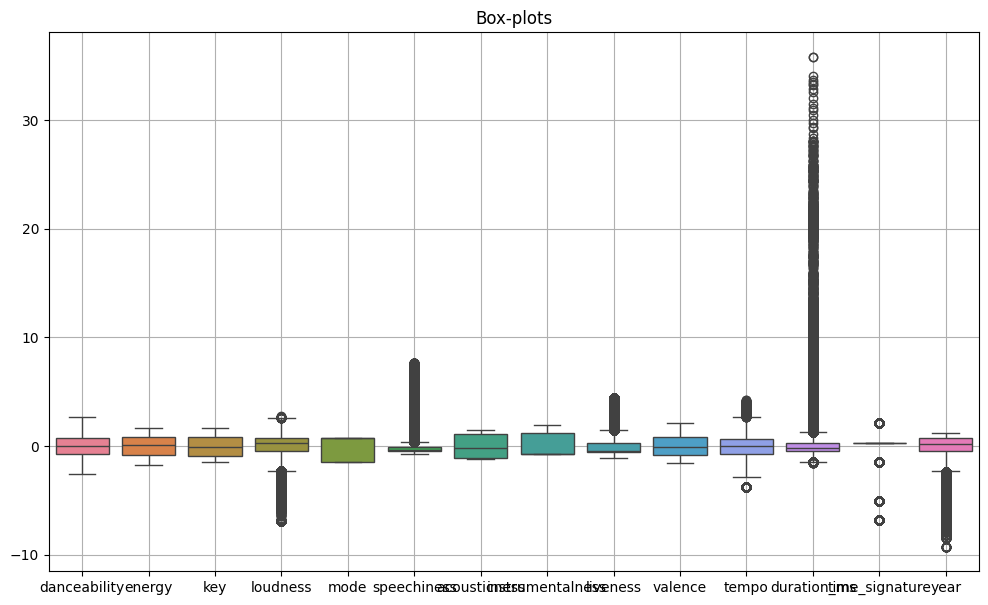

In [9]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=X_df)
plt.title('Box-plots')
plt.grid(True)
plt.show()

<Figure size 2000x1800 with 0 Axes>

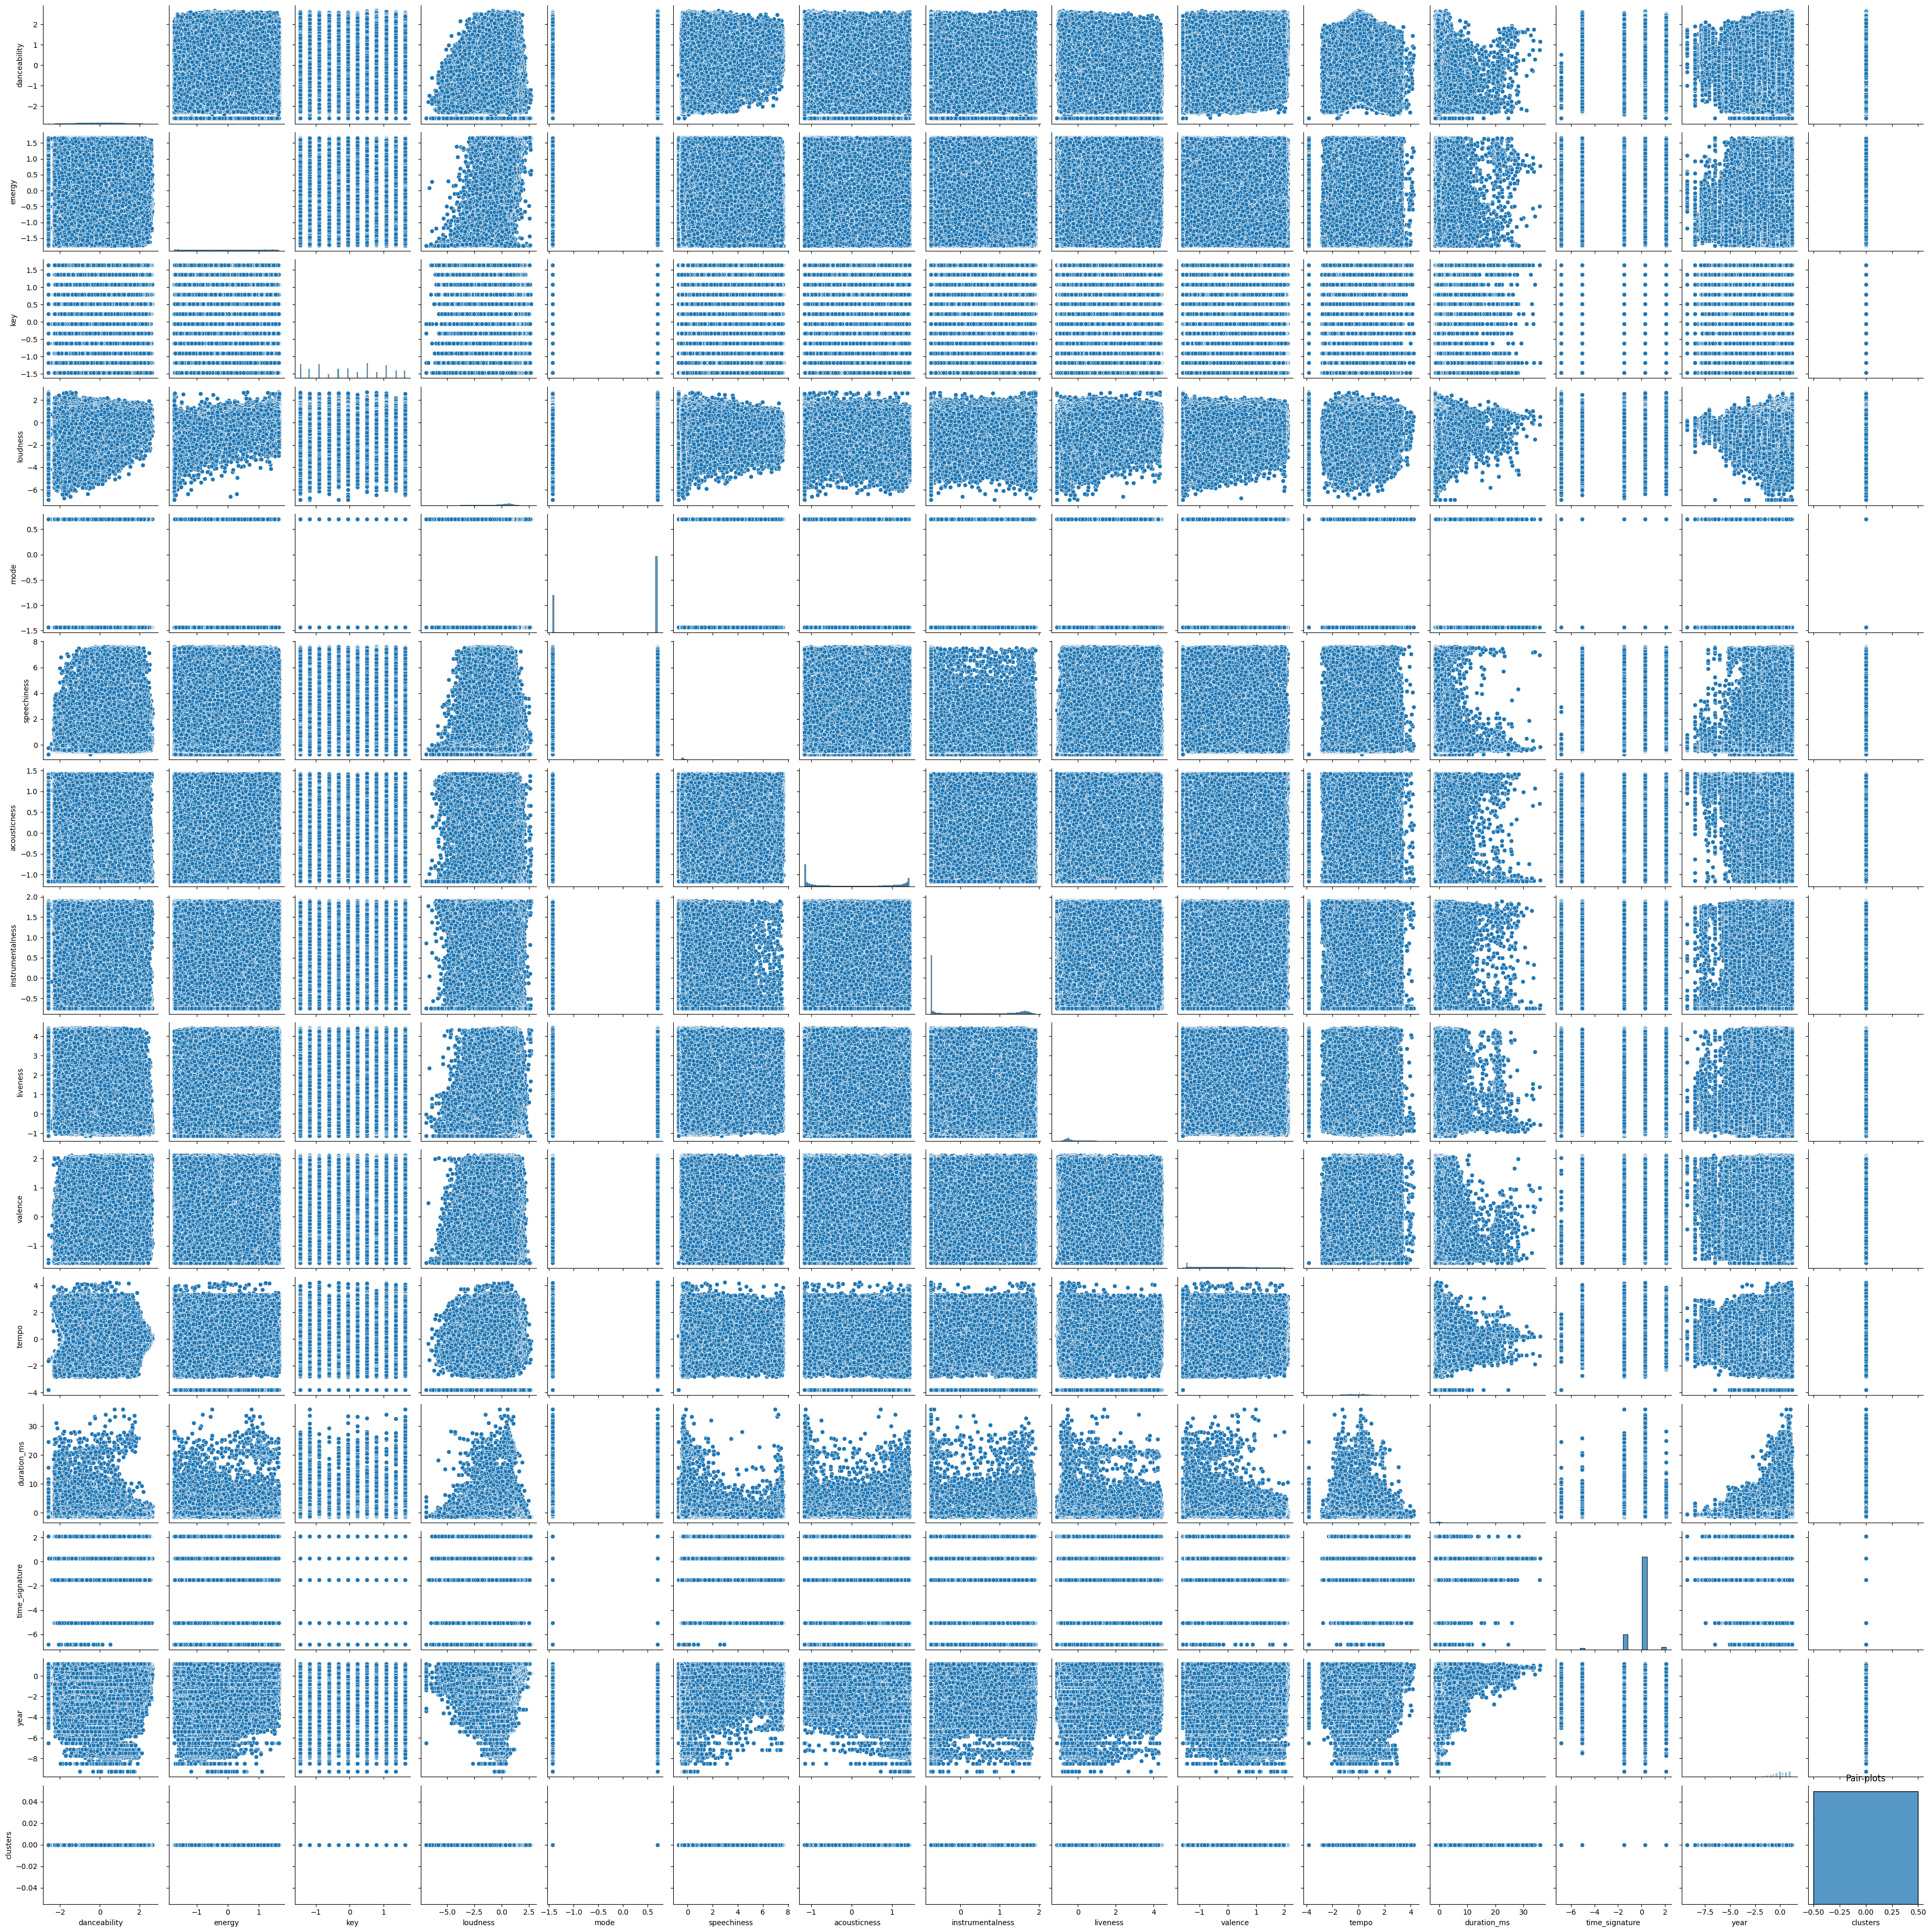

In [161]:
plt.figure(figsize=(20, 18))
sns.pairplot(data=X_df)
plt.title('Pair-plots')
plt.show()

In [89]:
X_df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
count,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06,1.203982e+06
mean,4.881808e-17,-1.148216e-16,5.195774e-17,-4.120737e-16,-1.323848e-16,3.726038e-16,-1.552358e-16,-1.831858e-17,-4.696734e-16,2.487645e-16,-4.160868e-16,-5.391707e-17,-3.572124e-16,2.168014e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.599533e+00,-1.729093e+00,-1.468637e+00,-6.902067e+00,-1.429600e+00,-7.274797e-01,-1.159780e+00,-7.517117e-01,-1.117148e+00,-1.582282e+00,-3.802378e+00,-1.527883e+00,-6.829426e+00,-9.264596e+00
25%,-7.225857e-01,-8.739456e-01,-9.031440e-01,-4.933206e-01,-1.429600e+00,-4.248754e-01,-1.062169e+00,-7.516915e-01,-5.807427e-01,-8.761391e-01,-7.621957e-01,-4.608160e-01,2.984858e-01,-5.037312e-01
50%,4.190119e-02,4.907066e-02,-5.490438e-02,2.891002e-01,6.994964e-01,-3.429740e-01,-1.499241e-01,-7.302385e-01,-4.244758e-01,-9.235755e-02,-2.935043e-02,-1.510324e-01,2.984858e-01,1.556887e-01
75%,7.378478e-01,8.702836e-01,7.933353e-01,7.292208e-01,6.994964e-01,-1.041666e-01,1.075402e+00,1.159084e+00,2.404898e-01,7.986394e-01,6.274692e-01,2.281118e-01,2.984858e-01,7.209058e-01
max,2.672790e+00,1.664349e+00,1.641575e+00,2.727308e+00,6.994964e-01,7.626467e+00,1.425866e+00,1.905863e+00,4.424231e+00,2.114801e+00,4.244115e+00,3.583165e+01,2.080464e+00,1.191920e+00


<Axes: >

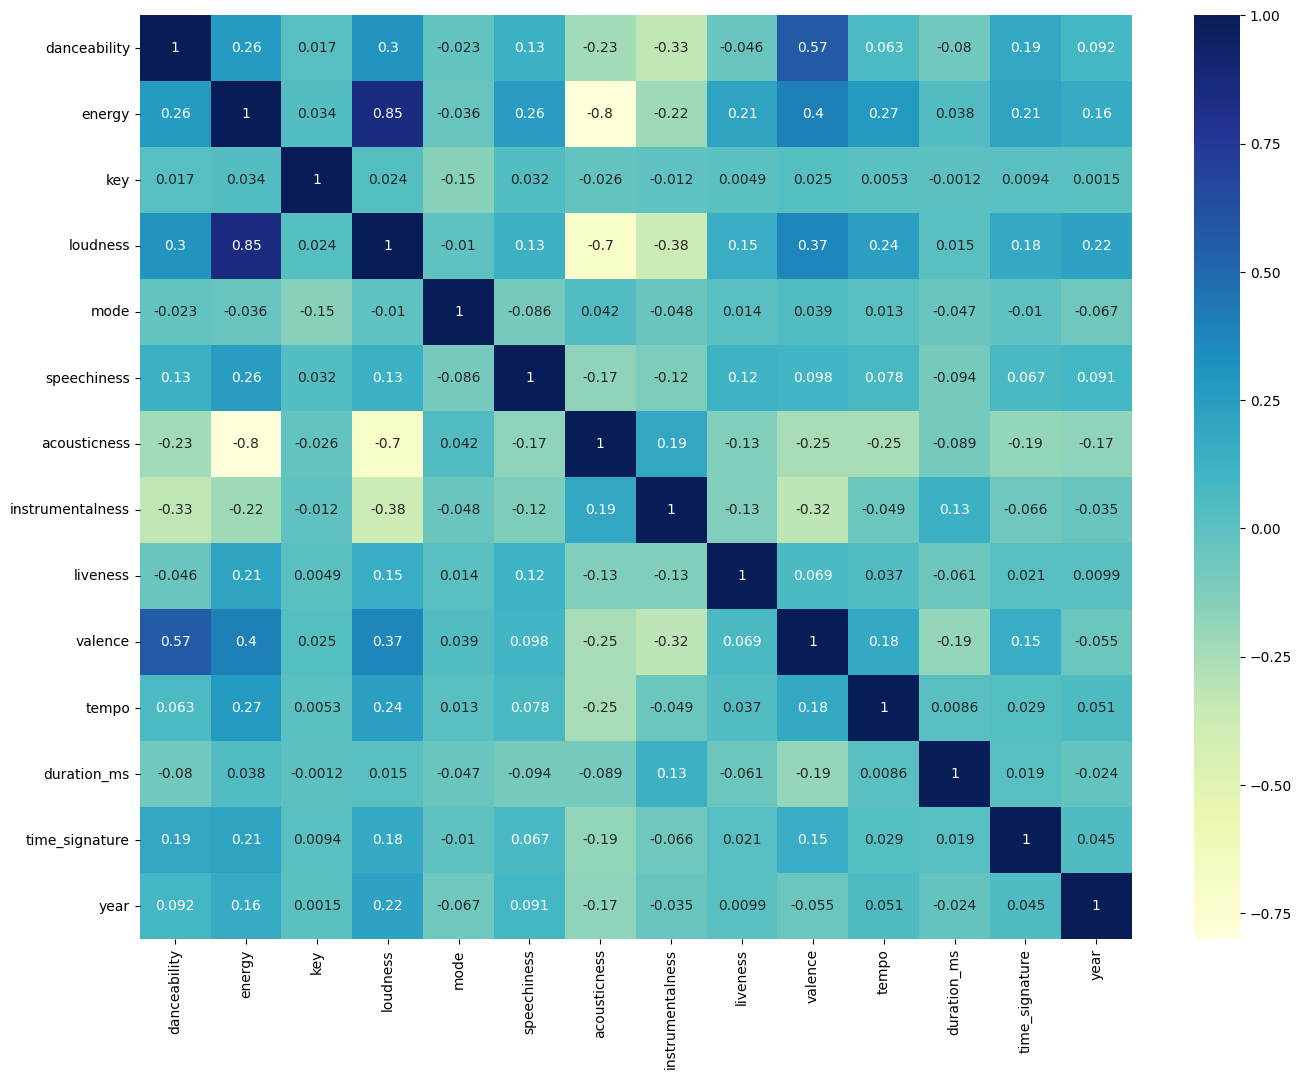

In [23]:
corr_m = X_df.corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(corr_m, cmap="YlGnBu", annot=True)

## Kmeans

In [ ]:
sse = {}

for k in range(2, 71):
    if k % 5 == 0:
        print(f'k_clusters: {k}')
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(X_df)
    # X_df['clusters'] = kmeans.labels_
    label = kmeans.labels_
    # sil_coeff = silhouette_score(X_df, label)
    # print("For k={}, The Silhouette Coefficient is {}".format(k, sil_coeff))
    sse[k] = kmeans.inertia_ 

k_clusters: 5
k_clusters: 10
k_clusters: 15
k_clusters: 20
k_clusters: 25
k_clusters: 30
k_clusters: 35
k_clusters: 40
k_clusters: 45
k_clusters: 50
k_clusters: 55
k_clusters: 60
k_clusters: 65
k_clusters: 70


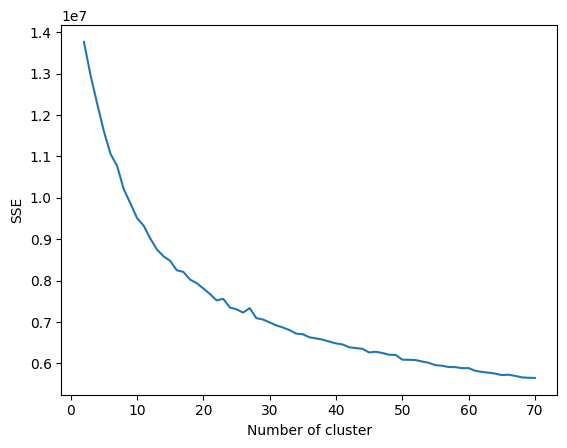

In [115]:
plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()

Так как данных очень много (1.2 млн) считать силуэт очень долго, поэтому будем прикидывать его на 1/50 от всей выборки

Зафиксируем некоторый батч, на котором будем оценивать качество

In [8]:
np.random.seed(9146291)
batch = np.random.choice(X_df.index, size=int(X_df.shape[0]/50), replace=False)

In [25]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(X_df)
    label = kmeans.labels_
    sil_coeff = silhouette_score(X_df.iloc[batch], label[batch])
    print("For k clusters={}, The Silhouette Coefficient is {}".format(k, sil_coeff))

For k clusters=2, The Silhouette Coefficient is 0.20228285413306848
For k clusters=3, The Silhouette Coefficient is 0.12890809520335894
For k clusters=4, The Silhouette Coefficient is 0.1203044020544664
For k clusters=5, The Silhouette Coefficient is 0.11430401114044919
For k clusters=6, The Silhouette Coefficient is 0.09027438091411392
For k clusters=7, The Silhouette Coefficient is 0.10157281832660707
For k clusters=8, The Silhouette Coefficient is 0.11389241348916601
For k clusters=9, The Silhouette Coefficient is 0.11523689433625307
For k clusters=10, The Silhouette Coefficient is 0.09449337772718373


In [26]:
X_df_short = X_df.iloc[batch]

In [27]:
X_df_short.shape

(24079, 14)

In [74]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_df_short)  

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [75]:
agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_clustering.fit(X_df_short) 

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [65]:
# TODO: play with parametrs
dbscan_cl = DBSCAN(eps=7, min_samples=1000, n_jobs=-1) 
dbscan_cl.fit(X_df_short)  

,eps,7
,min_samples,1000
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,-1


In [76]:
kmeans_clusters = kmeans.labels_
agg_clusters = agg_clustering.labels_
dbscan_clusters = dbscan_cl.labels_

In [77]:
print('kmeans siluet score' ,silhouette_score(X_df_short, kmeans_clusters))
print('agglomerative siluet score',silhouette_score(X_df_short, agg_clusters))
print('DBSCAN siluet score',silhouette_score(X_df_short, dbscan_clusters))

kmeans siluet score 0.11302689315157285
agglomerative siluet score 0.12939489277153177
DBSCAN siluet score 0.7678016785792136


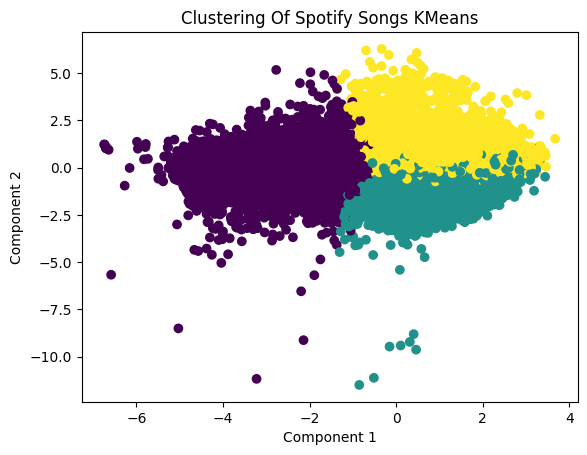

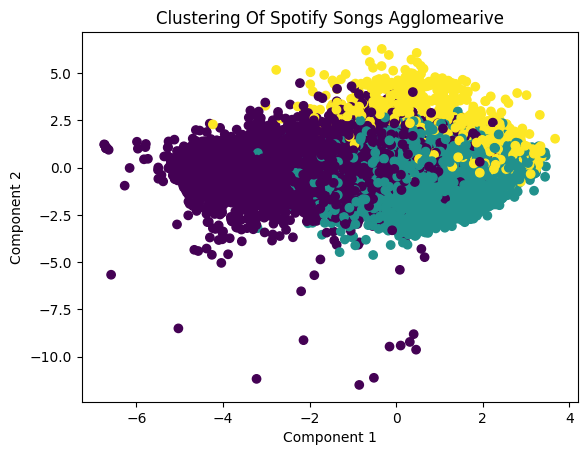

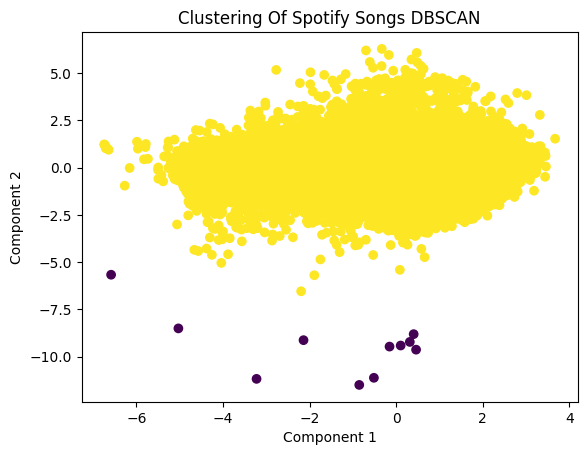

In [79]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_df_short)

def plot_clusters(clusters, title=None):
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters)
    plt.title(f'Clustering Of Spotify Songs {title}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()


plot_clusters(kmeans_clusters, title='KMeans')
plot_clusters(agg_clusters, title='Agglomearive')
plot_clusters(dbscan_clusters, title='DBSCAN')

In [85]:
def print_each_cluster(cluster_, rows=3, cols=1):
    unique_clusters = np.unique(cluster_)
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 12), sharex=True, sharey=True)
    axs = axs.flatten()
    for i, cluster in enumerate(unique_clusters):
        df_cluster = X_2d[cluster_ == cluster]
        
        df_other_clusters = X_2d[cluster_ != cluster]
        
        axs[i].scatter(df_other_clusters[:, 0], df_other_clusters[:, 1], c='gray', label='Other clusters', alpha=0.5)
        
        axs[i].scatter(df_cluster[:, 0], df_cluster[:, 1], c='red', label='Cluster {}'.format(cluster))
        
        axs[i].set_xlabel('Component 1')
        axs[i].set_ylabel('Component 2')
        
        axs[i].legend()

    plt.show()

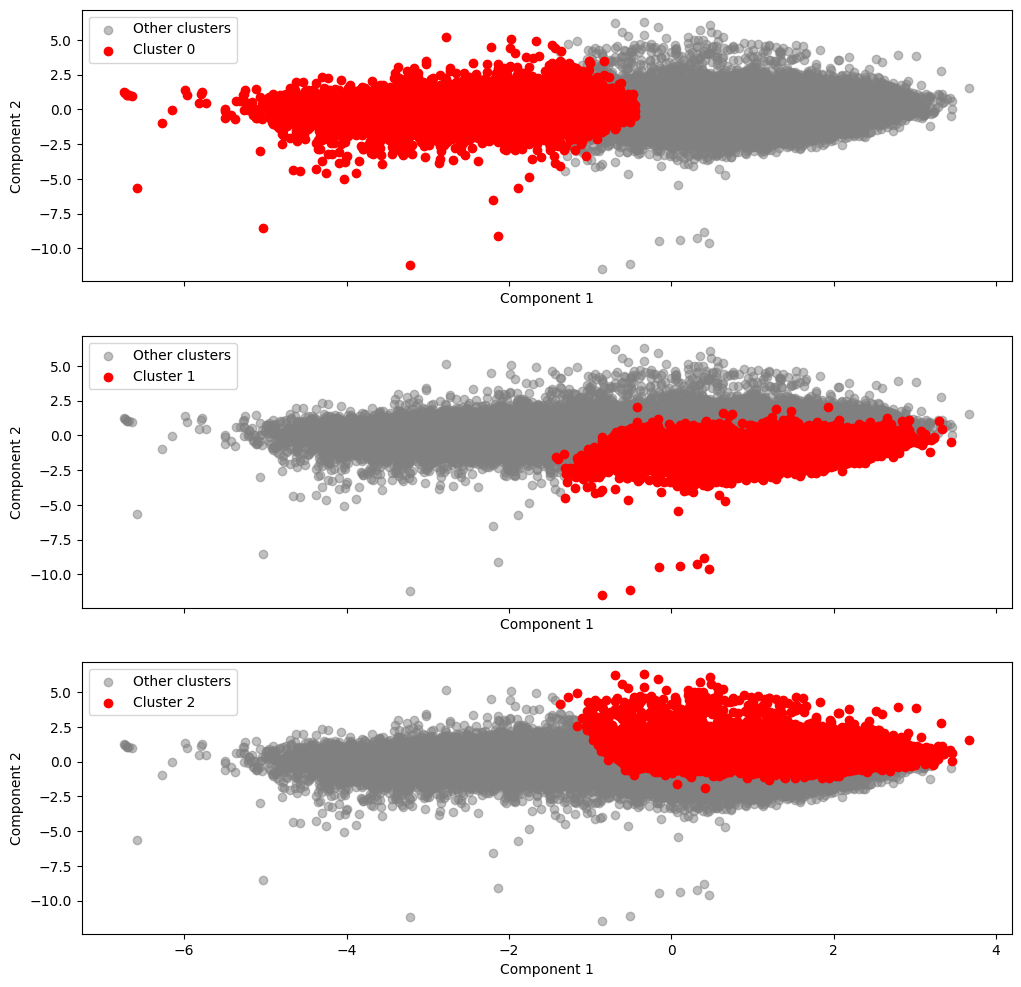

In [86]:
print_each_cluster(kmeans_clusters)

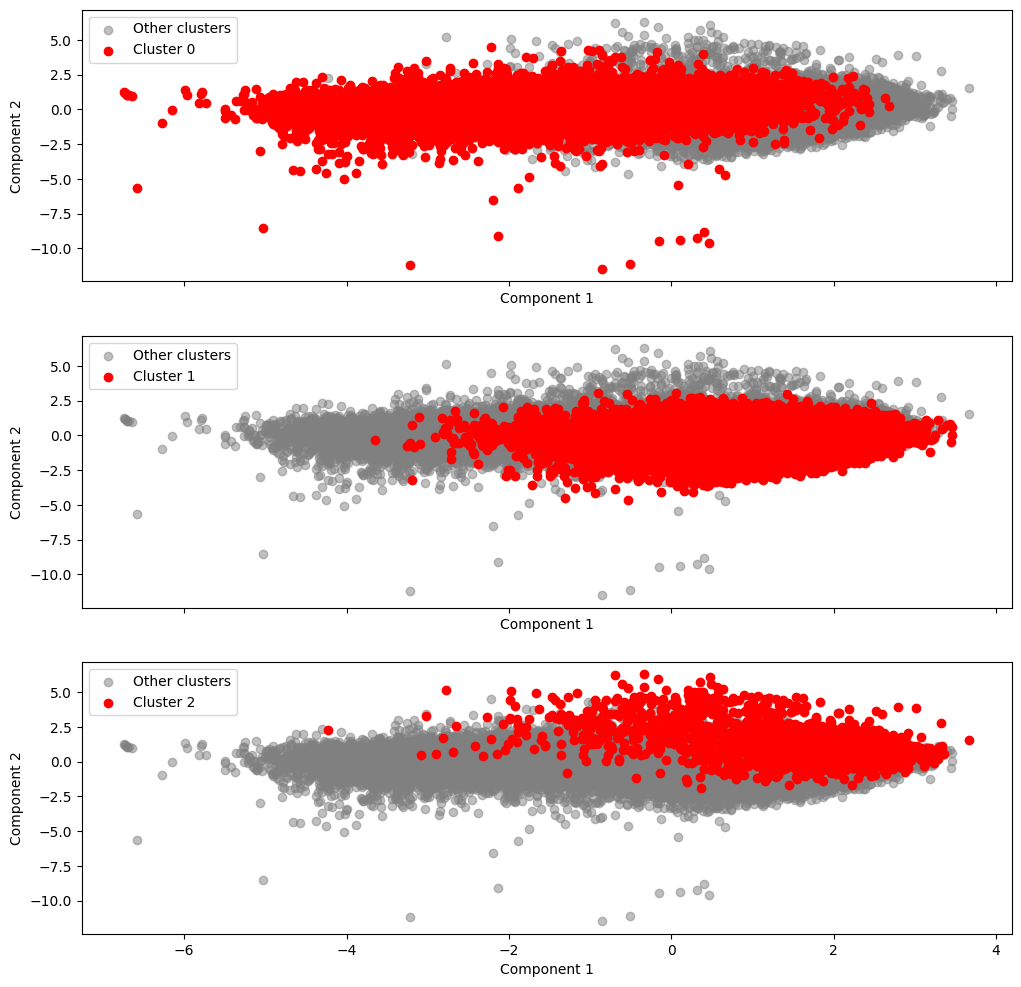

In [87]:
print_each_cluster(agg_clusters)

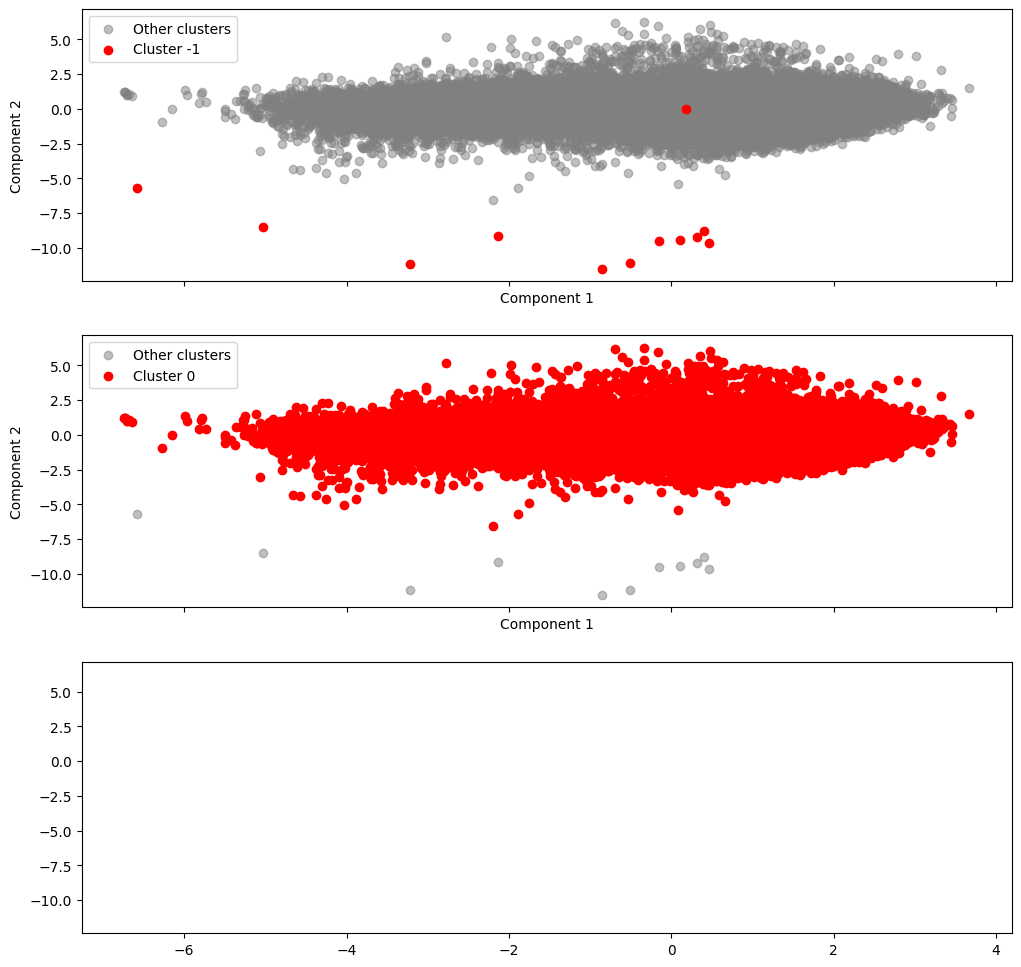

In [88]:
print_each_cluster(dbscan_clusters)